<a href="https://www.kaggle.com/code/adityasajgotra/cancer-detection?scriptVersionId=315573739" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras
import os

2026-04-30 12:52:45.699214: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777553566.047192      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777553566.152567      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777553567.009509      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777553567.009562      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777553567.009565      23 computation_placer.cc:177] computation placer alr

In [2]:
tf.random.set_seed(42)

In [3]:
path_part_1 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1"
path_part_2 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2"

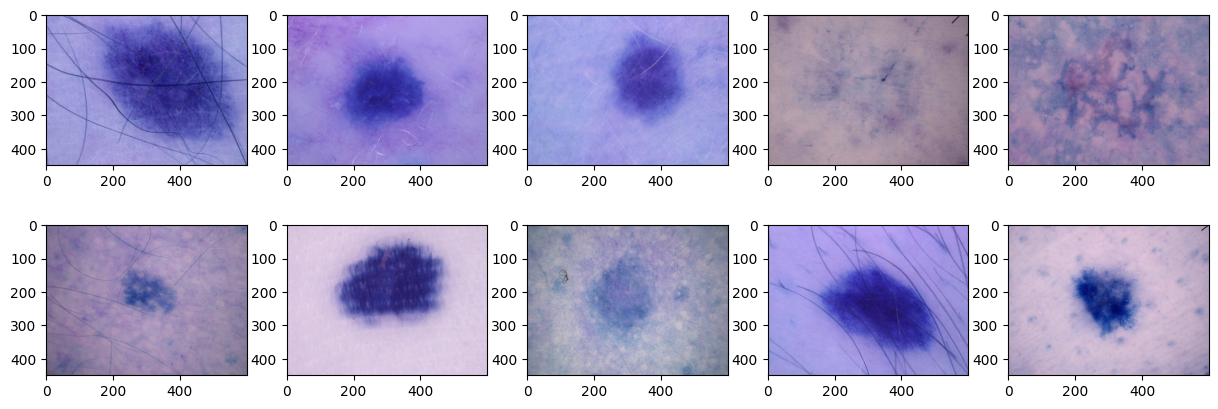

In [4]:
plt.figure(figsize=(15,5))
for i in range(0,10):
    plt.subplot(2,5,i + 1)
    if i < 5:
        img = cv2.imread(os.path.join(path_part_1, os.listdir(path_part_1)[i]))
    else:
        img = cv2.imread(os.path.join(path_part_2, os.listdir(path_part_2)[i]))
    plt.imshow(img)


In [5]:
img1 = cv2.imread(os.path.join(path_part_1, os.listdir(path_part_1)[0]))
img2 = cv2.imread(os.path.join(path_part_1, os.listdir(path_part_1)[1]))
print(img1.shape)
print(img2.shape)

(450, 600, 3)
(450, 600, 3)


In [6]:
df = pd.read_csv("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [8]:
df.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization
3260,HAM_0002632,ISIC_0029943,nv,follow_up,50.0,female,genital
1071,HAM_0002965,ISIC_0026446,bkl,consensus,75.0,female,lower extremity
5446,HAM_0001784,ISIC_0026450,nv,follow_up,35.0,male,abdomen
2454,HAM_0001860,ISIC_0027665,vasc,consensus,50.0,male,abdomen
9229,HAM_0001541,ISIC_0028766,nv,consensus,30.0,male,trunk


In [9]:
df["dx"].value_counts()/len(df)

dx
nv       0.669496
mel      0.111133
bkl      0.109735
bcc      0.051323
akiec    0.032651
vasc     0.014179
df       0.011483
Name: count, dtype: float64

In [10]:
x = df.iloc[:,:-1]
y = df.iloc[:,2]

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [12]:
df.isna().sum()/len(df)


lesion_id       0.000000
image_id        0.000000
dx              0.000000
dx_type         0.000000
age             0.005691
sex             0.000000
localization    0.000000
dtype: float64

In [13]:
df.dropna(inplace=True,axis=0)

In [14]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

train_idx, test_idx = next(sgkf.split(df, df["dx"], groups=df["lesion_id"]))


In [15]:
train = df.iloc[train_idx]
test = df.iloc[test_idx]

In [16]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7956 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     7956 non-null   object 
 1   image_id      7956 non-null   object 
 2   dx            7956 non-null   object 
 3   dx_type       7956 non-null   object 
 4   age           7956 non-null   float64
 5   sex           7956 non-null   object 
 6   localization  7956 non-null   object 
dtypes: float64(1), object(6)
memory usage: 497.2+ KB


In [17]:
train["dx"].value_counts()/len(train) #ratio of each class

dx
nv       0.671443
mel      0.112117
bkl      0.108220
bcc      0.050779
akiec    0.032428
vasc     0.013449
df       0.011564
Name: count, dtype: float64

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler,OrdinalEncoder

num_pip = Pipeline([
    ('scaler',StandardScaler())
])
cat_pip = Pipeline([
    ("encode",OneHotEncoder(sparse_output=False))
])

label_pip = Pipeline([
    ("label",OrdinalEncoder())
])

full_pipeline = ColumnTransformer([
    ("num",num_pip,['age']),
    ("cat",cat_pip,["sex","localization","dx"])

],remainder="passthrough")

In [19]:
imgs = tf.data.Dataset.list_files("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/*/*.jpg")

I0000 00:00:1777553607.847677      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [20]:
for i in imgs:
    print(tf.strings.split(tf.strings.split(i,os.path.sep)[-1],".")[0])
    break
#tf.strings.split(tf.strings.split(i,os.path.sep)[-1],".")[0] extracts the id from the image file name

tf.Tensor(b'ISIC_0029221', shape=(), dtype=string)


In [21]:
train.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization
5572,HAM_0003898,ISIC_0028713,nv,follow_up,45.0,male,foot
5872,HAM_0007140,ISIC_0026345,nv,follow_up,35.0,female,trunk
747,HAM_0001878,ISIC_0025434,bkl,histo,60.0,female,chest
5002,HAM_0006783,ISIC_0025624,nv,follow_up,55.0,male,trunk
2634,HAM_0004536,ISIC_0025644,bcc,histo,40.0,female,back


In [22]:
final_train = full_pipeline.fit_transform(train)

In [23]:
final_test = full_pipeline.transform(test)

In [24]:
full_pipeline.get_feature_names_out()

array(['num__age', 'cat__sex_female', 'cat__sex_male', 'cat__sex_unknown',
       'cat__localization_abdomen', 'cat__localization_acral',
       'cat__localization_back', 'cat__localization_chest',
       'cat__localization_ear', 'cat__localization_face',
       'cat__localization_foot', 'cat__localization_genital',
       'cat__localization_hand', 'cat__localization_lower extremity',
       'cat__localization_neck', 'cat__localization_scalp',
       'cat__localization_trunk', 'cat__localization_unknown',
       'cat__localization_upper extremity', 'cat__dx_akiec',
       'cat__dx_bcc', 'cat__dx_bkl', 'cat__dx_df', 'cat__dx_mel',
       'cat__dx_nv', 'cat__dx_vasc', 'remainder__lesion_id',
       'remainder__image_id', 'remainder__dx_type'], dtype=object)

In [25]:
train = pd.DataFrame(
    final_train,columns = full_pipeline.get_feature_names_out()
)
test = pd.DataFrame(
    final_test,columns = full_pipeline.get_feature_names_out()
)

In [26]:
train.sample(5)

,num__age,cat__sex_female,cat__sex_male,cat__sex_unknown,cat__localization_abdomen,cat__localization_acral,cat__localization_back,cat__localization_chest,cat__localization_ear,cat__localization_face,...,cat__dx_akiec,cat__dx_bcc,cat__dx_bkl,cat__dx_df,cat__dx_mel,cat__dx_nv,cat__dx_vasc,remainder__lesion_id,remainder__image_id,remainder__dx_type
1777,1.940889,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,HAM_0007511,ISIC_0024630,histo
3352,-0.982515,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,HAM_0000360,ISIC_0025854,follow_up
5771,-0.105494,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,HAM_0006187,ISIC_0028214,histo
6908,-1.274856,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,HAM_0004897,ISIC_0024352,histo
2945,0.186847,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,HAM_0003900,ISIC_0027868,follow_up


In [27]:
train.columns

Index(['num__age', 'cat__sex_female', 'cat__sex_male', 'cat__sex_unknown',
       'cat__localization_abdomen', 'cat__localization_acral',
       'cat__localization_back', 'cat__localization_chest',
       'cat__localization_ear', 'cat__localization_face',
       'cat__localization_foot', 'cat__localization_genital',
       'cat__localization_hand', 'cat__localization_lower extremity',
       'cat__localization_neck', 'cat__localization_scalp',
       'cat__localization_trunk', 'cat__localization_unknown',
       'cat__localization_upper extremity', 'cat__dx_akiec', 'cat__dx_bcc',
       'cat__dx_bkl', 'cat__dx_df', 'cat__dx_mel', 'cat__dx_nv',
       'cat__dx_vasc', 'remainder__lesion_id', 'remainder__image_id',
       'remainder__dx_type'],
      dtype='object')

In [28]:
arr = [0]*19  + ["","","","",""]
arr

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, '', '', '', '', '']

In [29]:
def make_csv(train,test):
    img_file1 = os.listdir("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1")
    img_file1 = set(map(lambda x : x.split(".")[0],img_file1))
    path1 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/"
    path2 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2/"
    train["path"] = np.where(train["remainder__image_id"].isin(img_file1), path1+train["remainder__image_id"]+".jpg",path2+train["remainder__image_id"]+".jpg")
    test["path"] = np.where(test["remainder__image_id"].isin(img_file1), path1+test["remainder__image_id"]+".jpg",path2+test["remainder__image_id"]+".jpg")
    test.to_csv("test.csv",index=False)
    train.to_csv("train.csv",index=False)
    
    print("csv successfully executed")

In [30]:
make_csv(train,test)

csv successfully executed


In [31]:
train = pd.read_csv("/kaggle/working/train.csv")
train.sample(5)

,num__age,cat__sex_female,cat__sex_male,cat__sex_unknown,cat__localization_abdomen,cat__localization_acral,cat__localization_back,cat__localization_chest,cat__localization_ear,cat__localization_face,...,cat__dx_bcc,cat__dx_bkl,cat__dx_df,cat__dx_mel,cat__dx_nv,cat__dx_vasc,remainder__lesion_id,remainder__image_id,remainder__dx_type,path
146,1.356208,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,HAM_0007625,ISIC_0033736,histo,/kaggle/input/datasets/kmader/skin-cancer-mnis...
6410,0.186847,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,HAM_0001002,ISIC_0026348,histo,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4431,0.186847,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,HAM_0006504,ISIC_0031098,follow_up,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3843,0.186847,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,HAM_0003168,ISIC_0026228,follow_up,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1261,0.771528,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,HAM_0000322,ISIC_0033473,histo,/kaggle/input/datasets/kmader/skin-cancer-mnis...


In [32]:
test = pd.read_csv("/kaggle/working/test.csv")
test.columns == train.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [33]:
train.columns

Index(['num__age', 'cat__sex_female', 'cat__sex_male', 'cat__sex_unknown',
       'cat__localization_abdomen', 'cat__localization_acral',
       'cat__localization_back', 'cat__localization_chest',
       'cat__localization_ear', 'cat__localization_face',
       'cat__localization_foot', 'cat__localization_genital',
       'cat__localization_hand', 'cat__localization_lower extremity',
       'cat__localization_neck', 'cat__localization_scalp',
       'cat__localization_trunk', 'cat__localization_unknown',
       'cat__localization_upper extremity', 'cat__dx_akiec', 'cat__dx_bcc',
       'cat__dx_bkl', 'cat__dx_df', 'cat__dx_mel', 'cat__dx_nv',
       'cat__dx_vasc', 'remainder__lesion_id', 'remainder__image_id',
       'remainder__dx_type', 'path'],
      dtype='object')

In [34]:
def csv_parser(filepath):
    raw_file = tf.io.read_file(filepath)
    splitted_raw_file = tf.strings.split(raw_file,sep="\n")
    return tf.data.Dataset.from_tensor_slices(splitted_raw_file)

In [35]:
def map_label(infoline):
    decoded = tf.io.decode_csv(infoline,record_defaults = [[0.0]]*26 + [[""]]*4)
    img_raw = tf.io.read_file(decoded[-1])
    img_decoded = tf.io.decode_jpeg(img_raw,channels=3)
    img_decoded = tf.image.resize(img_decoded,[224,224])/255.0
    label = tf.cast(decoded[-11:-4],tf.float32)
    # return (img_decoded,decoded[:-5]), tf.reshape(label,[1])
    return img_decoded, label
    

In [36]:
raw = csv_parser("/kaggle/working/train.csv")
raw = raw.skip(1)
raw = raw.take(len(raw)-1)

In [37]:
raw_test = csv_parser("/kaggle/working/test.csv")
raw_test = raw_test.skip(1)
raw_test = raw_test.take(len(raw_test)-1)

In [38]:
train_ds = raw.map(map_label)
test_ds = raw_test.map(map_label)

In [39]:
count = len(train_ds)
count



7956

In [40]:
len(test_ds)

2002

In [41]:
train_ds = train_ds.shuffle(
    buffer_size=count, 
    seed=42, 
    reshuffle_each_iteration=False
)
len(train_ds)

7956

In [42]:

val_ds = train_ds.skip(int(count * 0.8)).batch(64).prefetch(tf.data.AUTOTUNE)
train_ds = train_ds.take(int(count * 0.8)).batch(64).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(64).prefetch(tf.data.AUTOTUNE)

In [43]:
len(train_ds)

100

In [44]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense,Input,RandomFlip,RandomRotation,GlobalMaxPooling2D,Concatenate,Dropout,GlobalAveragePooling2D

In [45]:
model_pre = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    weights='imagenet',
    include_top = False
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [46]:
model_pre.trainable = True

In [47]:
from tensorflow.keras import layers, regularizers


img_input = Input(shape=(224,224,3))
x = layers.RandomFlip("horizontal")(img_input)
x = layers.RandomRotation(0.1)(x)
model_augment = model_pre(x)
model_out = GlobalMaxPooling2D()(model_augment)
model_out = layers.BatchNormalization()(model_out)

# concat = Concatenate()([model_out,data_inp])

# dense2 = Dense(256,activation="relu")(model_out)
dense2 = Dense(128,activation="relu")(model_out)
# dense3 = Dense(64,activation="relu")(dense2)
dense2 = Dropout(0.4)(dense2)
# dense4 = Dense(32,activation="relu")(dense3)
# dense5 = Dense(16,activation="relu")(dense4)
# dense5 = Dropout(0.3)(dense5)
dense7 = Dense(7,activation="softmax")(dense2)

main_model = Model(inputs=[img_input],outputs=[dense7])

In [48]:
# from sklearn.utils import class_weight
# import numpy as np

# weights = class_weight.compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(train['label__dx']),
#     y=train['label__dx']
# )

# class_weights_dict = dict(enumerate(weights))

# print(class_weights_dict)


In [49]:
from tensorflow.keras.callbacks import EarlyStopping

early = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    min_delta=0.00001,
    patience=10,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=0
)

In [50]:
from tensorflow.keras import layers, regularizers

main_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=2), 
    metrics=[tf.keras.metrics.AUC(multi_label=True,num_labels = 7,name="auc")]
)


In [51]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr = ReduceLROnPlateau(
    monitor="val_auc",
    factor=0.1,
    patience=5,
    verbose=1,
    mode="auto",
    min_delta=0.00001,
    cooldown=0,
    min_lr=1e-6
)

In [52]:
main_model.fit(
    train_ds,
    epochs=300,
    validation_data=val_ds, 
    callbacks=[early,lr]
    # class_weight=class_weights_dict
)


Epoch 1/300


I0000 00:00:1777553673.486524      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


100/100 ━━━━━━━━━━━━━━━━━━━━ 117s 564ms/step - auc: 0.7072 - loss: 0.2946 - val_auc: 0.5630 - val_loss: 0.4963 - learning_rate: 0.0010
Epoch 2/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 523ms/step - auc: 0.8678 - loss: 0.1304 - val_auc: 0.5315 - val_loss: 0.8647 - learning_rate: 0.0010
Epoch 3/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 69s 515ms/step - auc: 0.8935 - loss: 0.1023 - val_auc: 0.5154 - val_loss: 1.1915 - learning_rate: 0.0010
Epoch 4/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 69s 517ms/step - auc: 0.8985 - loss: 0.0937 - val_auc: 0.5000 - val_loss: 1.3187 - learning_rate: 0.0010
Epoch 5/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 69s 518ms/step - auc: 0.9030 - loss: 0.0941 - val_auc: 0.5039 - val_loss: 1.2856 - learning_rate: 0.0010
Epoch 6/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 69s 515ms/step - auc: 0.9183 - loss: 0.0881 - val_auc: 0.5000 - val_loss: 1.3187 - learning_rate: 0.0010
Epoch 7/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 69s 516ms/step - auc: 0.9139 - loss: 0.0870 - val_auc: 0.5000 - val_loss: 1.3187 - learning_ra

In [53]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense,Input,RandomFlip,RandomRotation,GlobalMaxPooling2D,Concatenate,Dropout
def build_model(hp):
    img_input = Input(shape=(224,224,3))
    x = layers.RandomFlip("horizontal")(img_input)
    x = layers.RandomRotation(0.1)(x)
    model_augment = model_pre(x)
    model_out = GlobalMaxPooling2D()(model_augment)
    model_out = layers.BatchNormalization()(model_out)
    dense2 = Dense( units=hp.Int("units_1", 128, 512, step=64),activation=hp.Choice("act_1",["relu","elu","selu","tanh"]))(model_out)
    # dense3 = Dense(units=hp.Int("units_2",64,256,step=64),activation=hp.Choice("act_2",["relu","selu","elu","tanh"]))(dense2)
    dense2 = Dropout(rate=hp.Float("drop_1",0.1,0.5,step=0.1))(dense2)
    # dense4 = Dense(units=hp.Int("units_3",32,128,step=32),activation=hp.Choice("act_3",["relu","selu","elu","tanh"]))(dense3)
    # dense5 = Dense(units=hp.Int("units_4",16,48,step=16),activation=hp.Choice("act_4",["relu","selu","elu","tanh"]))(dense4)
    # dense5 = Dropout(rate=hp.Float("drop_2",0.1,0.5,step=0.1))(dense5)
    dense7 = Dense(7,activation="softmax")(dense2)

    main_model_tuned = Model(inputs=[img_input],outputs=[dense7])



    main_model_tuned.compile(
        optimizer="adam",
        loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=2), 
        metrics=[tf.keras.metrics.AUC(multi_label=True,num_labels = 7,name="auc")]
    )

    return main_model_tuned

In [54]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_auc",
    max_trials=10,        
    directory='skin_cancer_tuning',
    project_name='random_search_run'
)


In [55]:
tuner.search(
    train_ds, 
    validation_data=val_ds,  
    callbacks=[early, lr],
    epochs = 15
)

Trial 10 Complete [00h 18m 10s]
val_auc: 0.8070767521858215

Best val_auc So Far: 0.9256681799888611
Total elapsed time: 02h 44m 25s


In [56]:
best_model = tuner.get_best_models(num_models = 1)
main_model_tuned = best_model[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 326 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [57]:
main_model_tuned.fit(train_ds,
    initial_epoch = 15,
    epochs=300,
    validation_data=val_ds, 
    callbacks=[early,lr]
)

Epoch 16/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 101s 549ms/step - auc: 0.9375 - loss: 0.0778 - val_auc: 0.5678 - val_loss: 0.9570 - learning_rate: 0.0010
Epoch 17/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 72s 534ms/step - auc: 0.9542 - loss: 0.0622 - val_auc: 0.6643 - val_loss: 0.3688 - learning_rate: 0.0010
Epoch 18/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 524ms/step - auc: 0.9288 - loss: 0.0833 - val_auc: 0.6405 - val_loss: 0.4050 - learning_rate: 0.0010
Epoch 19/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 525ms/step - auc: 0.9430 - loss: 0.0624 - val_auc: 0.7211 - val_loss: 0.2838 - learning_rate: 0.0010
Epoch 20/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 530ms/step - auc: 0.9633 - loss: 0.0459 - val_auc: 0.7669 - val_loss: 0.3228 - learning_rate: 0.0010
Epoch 21/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - auc: 0.9722 - loss: 0.0416
Epoch 21: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 528ms/step - auc: 0.9722 - loss: 0.0416 - val_auc: 0.7971 - val_loss

In [58]:
pred = main_model.predict(test_ds)

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 281ms/step


In [59]:
main_model.evaluate(test_ds)

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - auc: 0.4038 - loss: 0.3477


[0.22703583538532257, 0.5715958476066589]

[0.05475369468331337, 0.9751693606376648]

In [60]:
main_model_tuned.evaluate(test_ds)

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - auc: 0.6606 - loss: 0.1580


[0.12220388650894165, 0.8926003575325012]

In [61]:
pred.shape

(2002, 7)

<Figure size 1000x800 with 0 Axes>

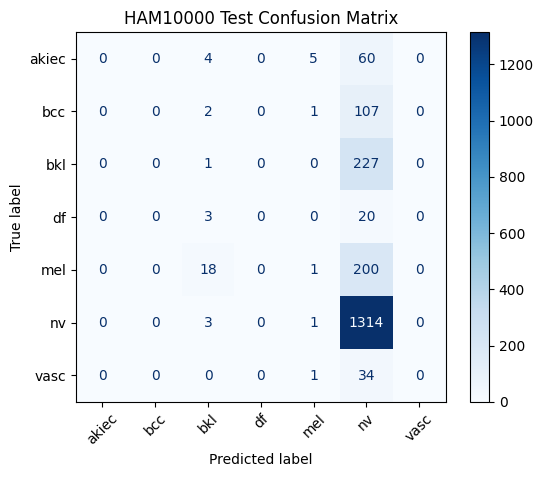

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Get the true labels (ensure they match the order of your 'pred' variable)
# This unbatches the dataset to get all labels as a single array
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# 2. Process your 'pred' (get the index of the highest probability)
y_pred_classes = np.argmax(pred, axis=1)

# 3. Handle y_true if it's one-hot encoded
if len(y_true.shape) > 1:
    y_true_classes = np.argmax(y_true, axis=1)
else:
    y_true_classes = y_true

# 4. Define HAM10000 labels
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

# 5. Plot
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('HAM10000 Test Confusion Matrix')
plt.xticks(rotation=45)
plt.show()


<Figure size 1200x900 with 0 Axes>

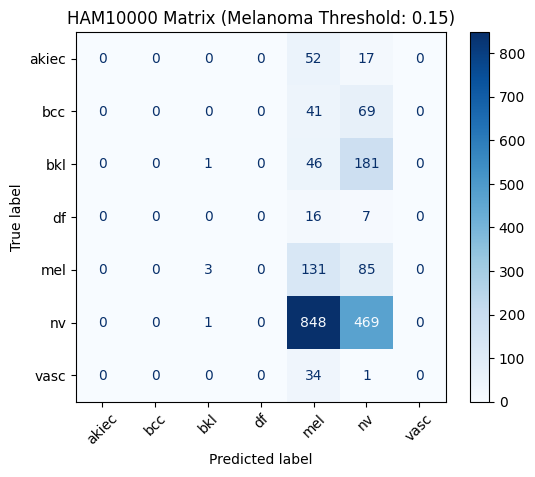

Total Melanomas in Test Set: 219
Melanomas Correctly Caught: 131 (59.82%)
Melanomas Missed: 88


In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- STEP 1: PREPARE DATA ---
# 1. Get true labels from the dataset (unbatching them)
y_true_raw = np.concatenate([y for x, y in test_ds], axis=0)

# 2. Handle both one-hot and integer labels for y_true
if len(y_true_raw.shape) > 1:
    y_true_indices = np.argmax(y_true_raw, axis=1)
else:
    y_true_indices = y_true_raw

# --- STEP 2: APPLY CUSTOM THRESHOLD ---
# 'pred' is your array from main_model.predict(test_ds)
# Index 4 is 'mel' (Melanoma) in the HAM10000 dataset
MEL_INDEX = 4
SAFETY_THRESHOLD = 0.15  # Lowered from 0.50 to catch more cancers

y_pred_adjusted = []

for p in pred:
    # If the probability of Melanoma is above our safety bar, prioritize it
    if p[MEL_INDEX] >= SAFETY_THRESHOLD:
        y_pred_adjusted.append(MEL_INDEX)
    else:
        # Otherwise, pick the class with the highest probability
        y_pred_adjusted.append(np.argmax(p))

y_pred_adjusted = np.array(y_pred_adjusted)

# --- STEP 3: PLOT THE NEW CONFUSION MATRIX ---
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
cm = confusion_matrix(y_true_indices, y_pred_adjusted)

plt.figure(figsize=(12, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')

plt.title(f'HAM10000 Matrix (Melanoma Threshold: {SAFETY_THRESHOLD})')
plt.xticks(rotation=45)
plt.show()

# --- STEP 4: PRINT SENSITIVITY CHECK ---
# Calculate how many Melanomas were caught vs total
total_mel = np.sum(y_true_indices == MEL_INDEX)
caught_mel = cm[MEL_INDEX, MEL_INDEX]
missed_mel = total_mel - caught_mel

print(f"Total Melanomas in Test Set: {total_mel}")
print(f"Melanomas Correctly Caught: {caught_mel} ({ (caught_mel/total_mel)*100 :.2f}%)")
print(f"Melanomas Missed: {missed_mel}")


In [64]:
main_model.export("model_tf")

INFO:tensorflow:Assets written to: model_tf/assets


INFO:tensorflow:Assets written to: model_tf/assets


Saved artifact at 'model_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')]
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  139888451930064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139886014219088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451936016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451942352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451941776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451940624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451942736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451941968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451943120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451943888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451943

In [65]:
main_model.save("model.keras")

In [66]:
main_model_tuned.export("model_tuned_tf")

INFO:tensorflow:Assets written to: model_tuned_tf/assets


INFO:tensorflow:Assets written to: model_tuned_tf/assets


Saved artifact at 'model_tuned_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')]
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  139883586079248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139883586076752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451936016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451942352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451941776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451940624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451942736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451941968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451943120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139888451943888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1398884519

In [67]:
main_model_tuned.save("model_tuned.keras")

In [68]:
main_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 1280)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,210,583 (27.51 MB)

 Trainable params: 2,391,303 (9.12 MB)

 Non-trainable params: 36,672 (143.25 KB)

 Optimizer params: 4,782,608 (18.24 MB)